### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [76]:
# get the sum of all NaN values in each column
nasum = data.isna().sum()

# create a new dataframe dropping the 'car' column
# this will be used to help calculate the percentage
# of rows with an empty value for that column
drop_car = data.drop("car", axis=1)

# drop all of the remaining rows that have at least
# one NaN value, then calculate the number of rows
# that were dropped.
drop_null = drop_car.dropna()
num_null = len(drop_car) - len(drop_null)

percent_car_empty = (nasum["car"] / len(data))
percent_other_empty = (num_null / len(drop_car))

# print all of the relevant values
print(nasum)
print(f'percent of rows with empty "car" field: {percent_car_empty:.2%}')
print(f'percent of rows with at least one NaN value (excluding "car" column): {percent_other_empty:.2%}')

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
percent of rows with empty "car" field: 99.15%
percent of rows with at least one NaN value (excluding "car" column): 4.77%


#### Missing data analysis
According to my initial analysis, a very large majority of the `car` column is missing data. In fact, it seems that 99.15% of the rows in the dataset have no data in the `car` column.

The other columns that contain missing data are the `Bar`, `CoffeeHouse`, `CarryAway`, `RestaurantLessThan20` and `Restaurant20To50` columns. I can immediately tell from the output of `.isna().sum()` that the amount of missing values in these columns is very small in relation to the total size of the dataset. The percentage of rows that contain at least one missing value (excluding the `car` column) is only 4.77%, so the amount of missing data outside of the `car` column is negligible.

3. Decide what to do about your missing data -- drop, replace, other...

#### Missing data decision
Because the vast majority of the `car` column contains no data, I decided to simply drop the entire column, the small amount of usable data in this column would not have any meaningful impact on a derived ML model or other data analysis.

I have also decided to drop all of the remaining rows that contain empty values in any of the other columns as well. Because the amount of rows with missing data represents less than 5% of the entire dataset, dropping those rows will not have a meaningful impact on any analysis.

The cleaned data will be stored in a new dataframe called `clean_df`.

In [ ]:
# clean up data by dropping the 'car' column and
# all remaining rows with empty values
drop_car = data.drop("car", axis=1)
clean_df = drop_car.dropna()

clean_df.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [75]:
# query the clean data for all coupons that
# were accepted and then find the percentage
# of accepted rows.
accepted = clean_df["Y"].mean()
print(f'coupon acceptance rate: {accepted:.2%}')

coupon acceptance rate: 56.93%


#### Total number of accepted coupons
It looks like a bit more than half of the coupons that were offered to customers were accepted, at 54.93%.

5. Use a bar plot to visualize the `coupon` column.

#### Coupon column visualization
To visually analyze the `coupon` column I will draw a bar plot using matplotlib, grouping all of the rows by their value in the `coupon` column and visualizing the number of accepted coupons against the total number of coupons for each type of coupon.
On the X-axis will be all of the unique values of the `coupon` column, those values being `Bar`, `Carry out & Take away`, `Coffee House`, `Restaurant(20-50)`, and `Restaurant(<20)`. On the Y-axis will be the count of coupons in each of those categories. The bar for each category will be split in two bars, the left bar being the `total` bar which represents the total number of coupons offered in that category and the right bar being the `accepted` bar which represents the number of coupons accepted in that category.

This visualiztion strategy will help me get a feel for which coupons were the most popular while also showing the relationship between the number of coupons offered and the portion of those that were accepted.

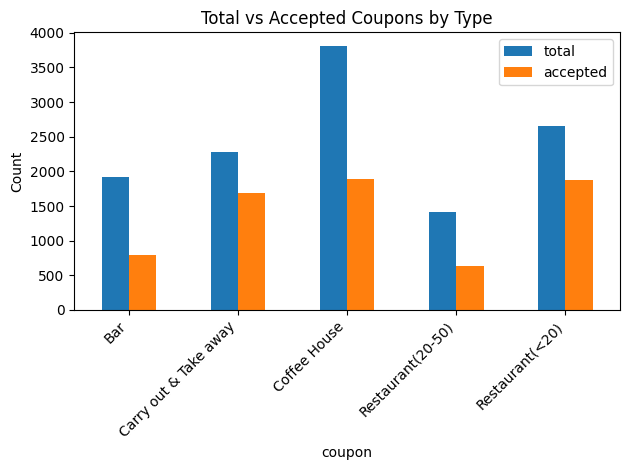

In [10]:
# group clean data by "coupon" and then aggregate the
# coupons by both the total number of rows and
# the sum of all accepted coupons. Then, plot the data
# in a bar plot.
counts = clean_df.groupby("coupon")["Y"].agg(total="count", accepted="sum")
counts.plot.bar()
plt.ylabel("Count")
plt.title("Total vs Accepted Coupons by Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

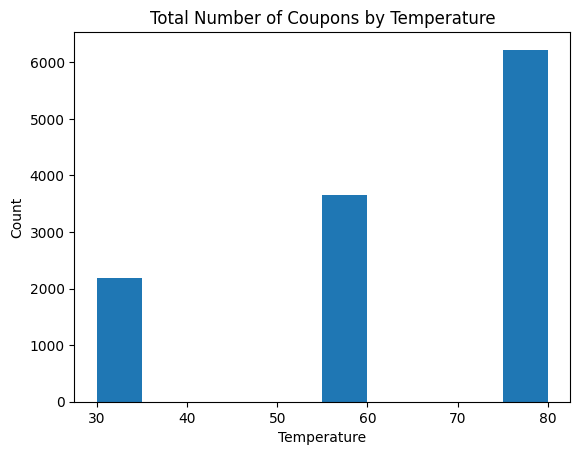

In [110]:
clean_df["temperature"].plot.hist()
plt.title("Total Number of Coupons by Temperature")
plt.ylabel("Count")
plt.xlabel("Temperature")
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [12]:
bar = clean_df[clean_df["coupon"] == "Bar"]
bar

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [73]:
percent_bar_accepted = bar["Y"].mean()
print(f'bar coupon acceptance rate: {percent_bar_accepted:.2%}')

bar coupon acceptance rate: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


3 or fewer acceptance rate: 37.27%
more than 3 acceptance rate: 76.17%


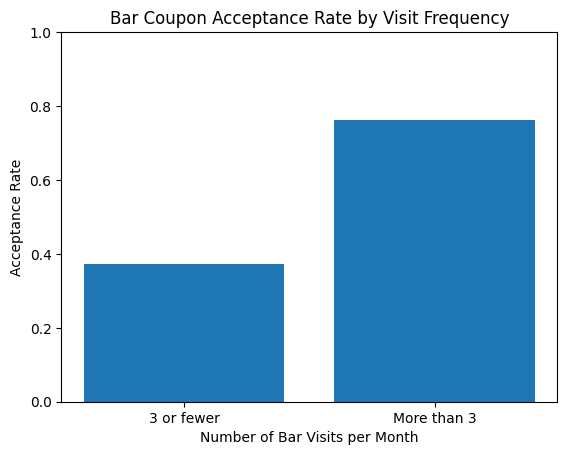

In [72]:
le3 = ["never", "less1", "1~3"]
bar_le_3 = bar[bar["Bar"].isin(le3)]
bar_gt_3 = bar[~bar["Bar"].isin(le3)]

percent_bar_le_3_accepted = bar_le_3["Y"].mean()
percent_bar_gt_3_accepted = bar_gt_3["Y"].mean()

print(f'3 or fewer acceptance rate: {percent_bar_le_3_accepted:.2%}')
print(f'more than 3 acceptance rate: {percent_bar_gt_3_accepted:.2%}')

plt.bar(['3 or fewer', 'More than 3'], [percent_bar_le_3_accepted, percent_bar_gt_3_accepted])
plt.ylabel('Acceptance Rate')
plt.xlabel('Number of Bar Visits per Month')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency')
plt.ylim(0, 1)
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


more than once, over 25 acceptance rate: 68.98%
others acceptance rate: 33.77%


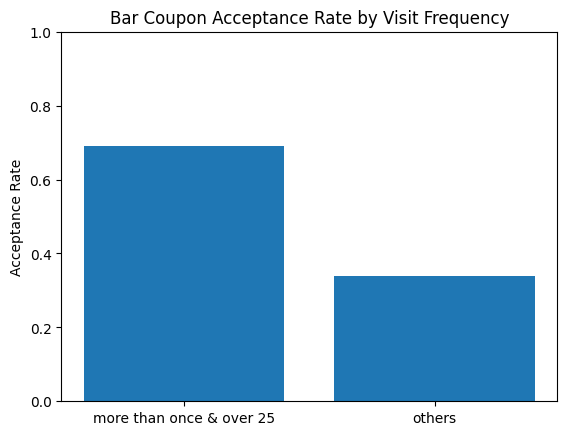

In [71]:

gt1 = ["1~3", "4~8", "gt8"]
younger25 = ["below21", "21"]
bar_gt1_over25 = bar[bar["Bar"].isin(gt1) & ~bar["age"].isin(younger25)]
percent_gt1_over25 = bar_gt1_over25["Y"].mean()

bar_others = bar[~(bar["Bar"].isin(gt1) & ~bar["age"].isin(younger25))]
percent_others = bar_others["Y"].mean()

print(f'more than once, over 25 acceptance rate: {percent_gt1_over25:.2%}')
print(f'others acceptance rate: {percent_others:.2%}')

plt.bar(['more than once & over 25', 'others'], [percent_gt1_over25, percent_others])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency')
plt.ylim(0, 1)
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


no kid, no farming acceptance rate: 70.94%
others acceptance rate: 29.79%


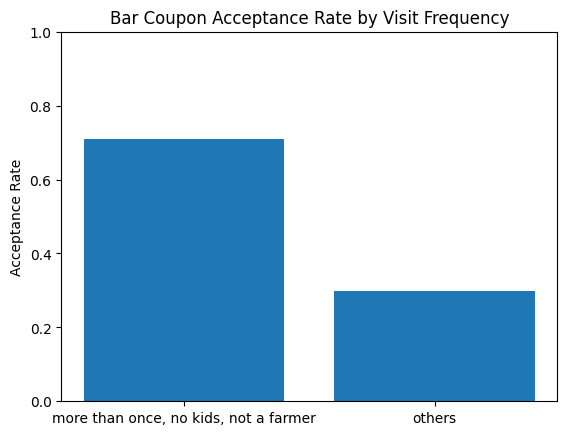

In [70]:

kid = ["Kid(s)"]
job = ["Farming Fishing & Forestry"]

bar_nokid_nofarming = bar[bar["Bar"].isin(gt1) & ~bar["passanger"].isin(kid) & ~bar["occupation"].isin(job)]
percent_nokid_nofarming = bar_nokid_nofarming["Y"].mean()

bar_others = bar[~(bar["Bar"].isin(gt1) & ~bar["passanger"].isin(kid) & ~bar["occupation"].isin(job))]
percent_others = bar_others["Y"].mean()

print(f'no kid, no farming acceptance rate: {percent_nokid_nofarming:.2%}')
print(f'others acceptance rate: {percent_others:.2%}')

plt.bar(['more than once, no kids, not a farmer', 'others'], [percent_nokid_nofarming, percent_others])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency')
plt.ylim(0, 1)
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



combined group acceptance rate: 58.71%
others acceptance rate: 29.99%


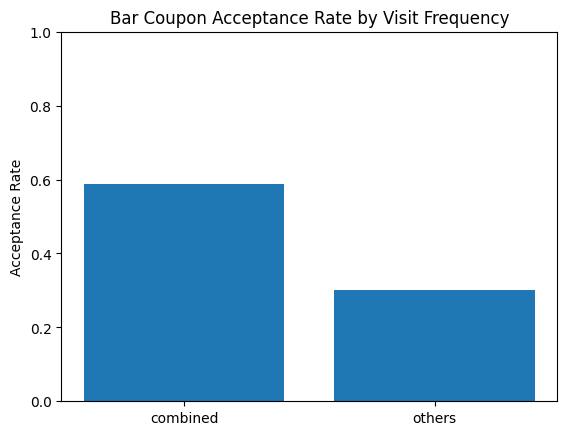

In [69]:
# age below 30
under_30 = ["below21", "21", "26"]

# income values under 50k
under_50k = ["Less than $12500", "$12500 - $24999", "$25000 - $37499", "$37500 - $49999"]

# condition 1: bars > 1, no kids, not widowed
c1 = bar["Bar"].isin(gt1) & ~(bar["passanger"] == "Kid(s)") & ~(bar['maritalStatus'] == 'Widowed')

# condition 2: bars > 1, under 30
c2 = bar["Bar"].isin(gt1) & bar["age"].isin(under_30)

# condition 3: cheap restaurant > 4, income < 50k
c3 = bar["RestaurantLessThan20"].isin(["4~8", "gt8"]) & bar['income'].isin(under_50k)

combined = bar[c1 | c2 | c3]
others = bar[~(c1 | c2 | c3)]

percent_combined = combined["Y"].mean()
percent_others = others["Y"].mean()

print(f'combined group acceptance rate: {percent_combined:.2%}')
print(f'others acceptance rate: {percent_others:.2%}')


plt.bar(['combined', 'others'], [percent_combined, percent_others])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency')
plt.ylim(0, 1)
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

#### Bar coupon conclusion
Overall, bar coupons are some of the least popular. The acceptance of bar coupons is lower than the average acceptance of all coupons, `41.2%` for bar coupons and `56.9%` for all coupons. This could be attributed to frequent bar-going being a slightly more niche behavior than other coupons in the dataset.

People who go to bars semi-frequently, at least 3 times a month, are much more likely to accept a bar coupon than customers who go to bars fewer than 3 times a month. `76.2%` of people who go to bars at least 3 times a month accepted the bar coupons, while only `37.3%` of people who went less than that accepted. This indicates that one of the strongest predictors of bar coupon acceptance is whether or not a customer is already a frequent bar patron.

The comparisons point to some other important indicators of bar coupon acceptance as well, one particularly strong one being age. Those over 25 seem to accept much more than those under 25, so slightly older bar-goers are more likely to accept.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Coffee House Coupon Analysis

I will be analyzing the details of the coupons for the Coffee House that are present in the dataset. I will explore the data to try to determine if any of the variables within the dataset have any significant impact on the Coffee House type coupons by examining various plots and data queries.

#### Initial setup/cleanup

First, because I am planning on analyzing how the time of day effects the acceptance rate of coffee house coupons, I am going to perform some initial cleaning up of the data by making sure that the time values are ordered correctly. In this dataset, the values of the `time` column are strings, including `7AM`, `10AM`, `2PM`, `6PM`, and `10PM`. By default, when creating a plot these values are not ordered sequentially along the x or y axis, so I will use the `pd.Categorical()` function to make sure that they are placed in the correct order.

Then I will create a new dataframe that is a subset of the original, cleaned data that only contains rows of the `Coffee House` coupon type.

In [91]:
time_order = ["7AM", "10AM", "2PM", "6PM", "10PM"]
clean_df["time"] = pd.Categorical(clean_df["time"], categories=time_order, ordered=True)

coffeeHouse = clean_df[clean_df["coupon"] == "Coffee House"]

#### Data exploration

Next I want to determine some basic qualities of the coffee house data subset. This will include the overall acceptance rate of coffee house coupons along with the acceptance rate of those coupons among a few different customer types that may have a correlation.

In [92]:
coffeeHouse_acceptance = coffeeHouse["Y"].mean()
print(f'the overall acceptance rate of coffee house coupons: {coffeeHouse_acceptance:.2%}')

the overall acceptance rate of coffee house coupons: 49.63%


I also want to analyze how specific types of customers accept coffee house coupons. Specifically, I want to know if people who visit coffee shops more frequently will have a higher acceptance rate.

In [112]:
gt3 = ["4~8", "gt8"]
coffeeHouse_gt3 = coffeeHouse[coffeeHouse["CoffeeHouse"].isin(gt3)]
coffeeHouse_le3 = coffeeHouse[~coffeeHouse["CoffeeHouse"].isin(gt3)]

coffeeHouse_gt3_acceptance = coffeeHouse_gt3["Y"].mean()
coffeeHouse_le3_acceptance = coffeeHouse_le3["Y"].mean()

print(f"acceptance rate of people who visit more than 3 times a month: {coffeeHouse_gt3_acceptance:.2%}")
print(f"acceptance rate of people who visit at most 3 times a month: {coffeeHouse_le3_acceptance:.2%}")

acceptance rate of people who visit more than 3 times a month: 67.26%
acceptance rate of people who visit at most 3 times a month: 44.59%


#### Acceptance by destination
I suspect that many people will be getting coffee on their way to work, so I want to determine the acceptance rate of people who's destination is work compared to all other destinations.

In [98]:
to_work = coffeeHouse[coffeeHouse["destination"] == "Work"]
to_other = coffeeHouse[~(coffeeHouse["destination"] == "Work")]

to_work_acceptance = to_work["Y"].mean()
to_other_acceptance = to_other["Y"].mean()

print(f'coffee coupon acceptance on the way to work: {to_work_acceptance:.2%}')
print(f'coffee coupon acceptance on the way to other: {to_other_acceptance:.2%}')

coffee coupon acceptance on the way to work: 44.00%
coffee coupon acceptance on the way to other: 51.31%


It turns out that my hypothesis was incorrect, more coffee coupons were accepted when the destination was not work than when it was work. To better visualize the acceptance by destination, I'll create a bar plot showing the acceptance by destination.

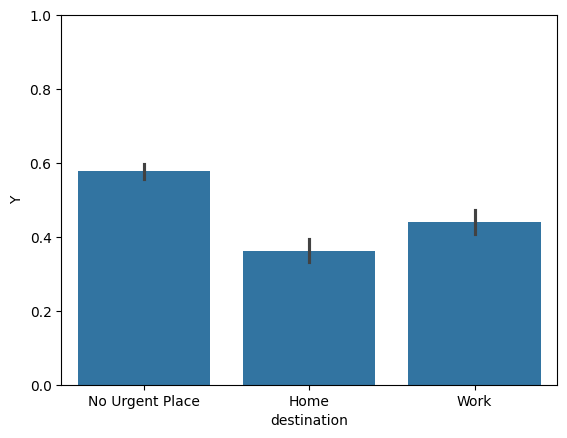

In [111]:
# seaborn barplots automatically take the mean of the y axis, which in
# this case also happens to calculate the acceptance rate.
sns.barplot(data=coffeeHouse, x="destination", y="Y")
plt.ylim(0, 1)
plt.show()

#### Acceptance by time

One relationship that I am interested in exploring is how the acceptance rate of coffee house coupons changes by time of day. I suspect that because most people primarily drink coffee in the morning the acceptance rate of coupons for the coffee house will be different in the morning than it will be in the evening.

I'll start by plotting the acceptance rate for each time of day in a bar plot.

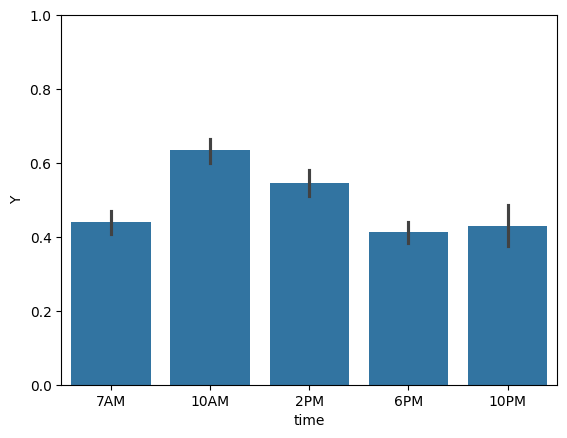

In [ ]:
sns.barplot(data=coffeeHouse, x="time", y="Y")
plt.ylim(0, 1)
plt.show()

#### Relating time to destination

I want to try to visualize the relationship between the time and travel destination of accepted coupons. I'll do this by creating heatmaps of the two values, with time on the Y-axis and destination on the X-axis. I will create two heatmaps, one showing the total number of accepted coupons for each square and one showing the acceptance rate of coupons for each square.

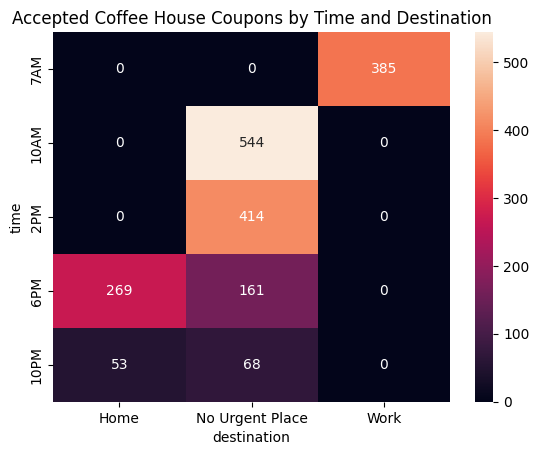

In [109]:
pivot = coffeeHouse[coffeeHouse["Y"] == 1].groupby(["time", "destination"]).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Accepted Coffee House Coupons by Time and Destination")
plt.show()

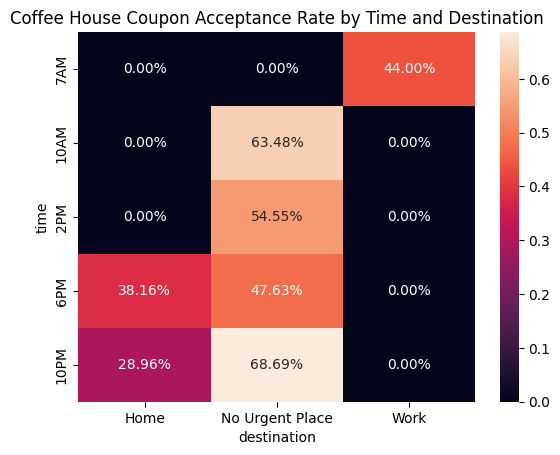

In [108]:
pivot = coffeeHouse.pivot_table(values="Y", index="time", columns="destination", aggfunc="mean", fill_value=0)
sns.heatmap(pivot, annot=True, fmt=".2%")
plt.title("Coffee House Coupon Acceptance Rate by Time and Destination")
plt.show()


Interestingly, the heatmaps show that the highest acceptance rates are at `10AM` and `10PM` while the destination is not urgent. This is very different from my initial hypothesis that most people would accept the coupons in the morning while heading to work. The highest acceptance rate was the `10PM`-`No Urgent Destination` slot, however the first heatmap also shows that this is one of the slots with the fewest offered coupons overall, so this might be a slot that could be added to in the future. 

#### Conclusion
My Initial hypothesis about the stereotypical "commuter coffee run" was incorrect when it comes to coupon acceptance. Customers don't seem to be very interested in using coupons to save money on their morning coffee. This could be due to the inherent urgency of needing to get to work at a specific time, so customers are not as worried about finding coupons at that time of their day. Another factor could be the habitual aspect. the "morning coffee run" is a very habitual event that most people will settle into a specific routine to accomplish. because of this, people do not seem willing to change their habits just because they received a coupon for a different coffee shop, even if the coffee would be cheaper because of it.

The best time to reach customers with coffee house coupons is during late morning/lunch and late in the evening and while the customer is on their way to no place in particular. This seems to indicate that customers are much more likely to take coupons to a coffee house on their leisure time when they don't have other, more important things to do.

##### Recommendations
Because it was found that most customers will accept a coffee house coupon while their leisure time, I recommend that more ways to target customers during those times are found. Perhaps by identifying more specific destinations, like common areas for lunch and dinner, more coupons could be pushed to customers as they are driving to those destinations.

I would also recommend serving more coupons during the 10PM slot as it seems that it has a very high acceptance rate but is currently not being served very many coupons relative to other time slots. This could be an opportunity to take advantage of when customers are most receptive to the coupons.

Repeat customers also seem to be more receptive to coupons, the >3 times a month customer accepted coupons at 67% while other customers only accepted 44.6% of the time. Serving more coupons to loyal customers would be an easy way to increase acceptance.